In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv(r"C:\Users\ritha\Downloads\retail_sales_dataset.csv")

In [9]:
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [7]:
print(df.describe())

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


In [8]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [17]:
df.dropna(inplace=True)

In [18]:
df.dropna(inplace=True)

In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [20]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Product Category'],
    drop_first=True
)

In [21]:
X = df.drop(
    columns=[
        'Transaction ID',
        'Customer ID',
        'Date',
        'Total Amount'
    ]
)

y = df['Total Amount']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
predictions = model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", mae)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 160.2748117004751
Root Mean Squared Error : 197.28215453151694
R2 Score : 0.8703203373035876


In [26]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

print(comparison.head(10))

   Actual    Predicted
0      75   158.365500
1      50  -152.212937
2     900   843.550064
3    2000  1525.636082
4     600   679.500977
5     500   960.695550
6    1500  1322.201791
7     200   394.280162
8     150   213.278844
9      25  -211.805378


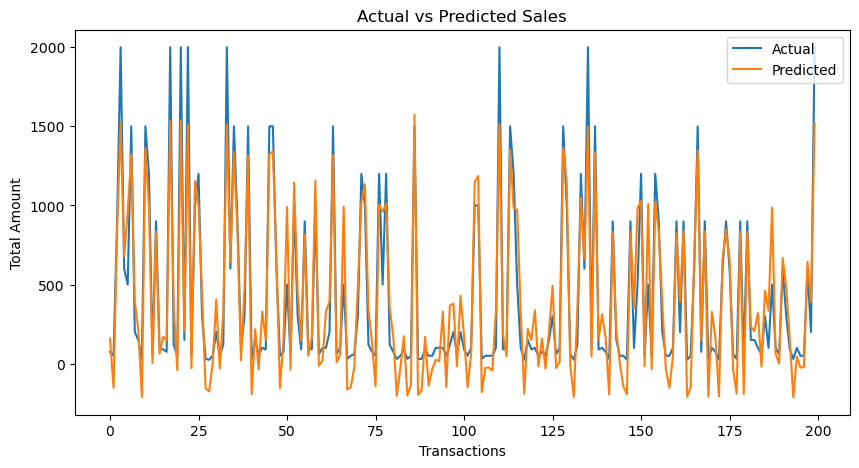

In [27]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.xlabel("Transactions")

plt.ylabel("Total Amount")

plt.title("Actual vs Predicted Sales")

plt.legend()

plt.show()

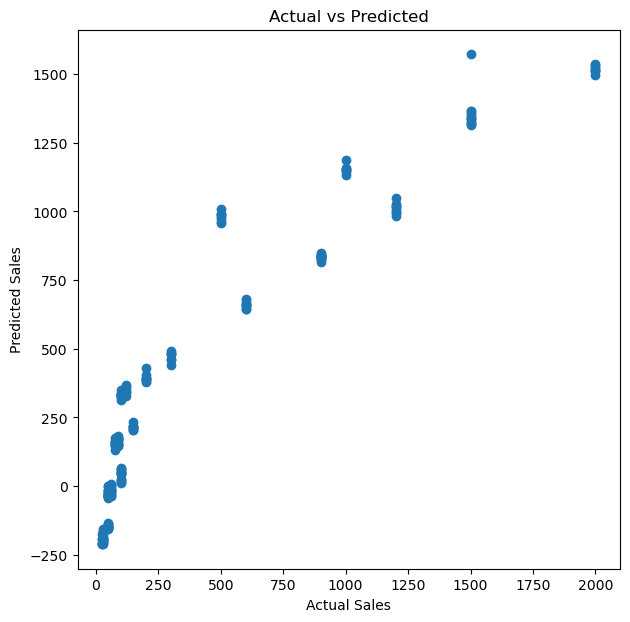

In [28]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

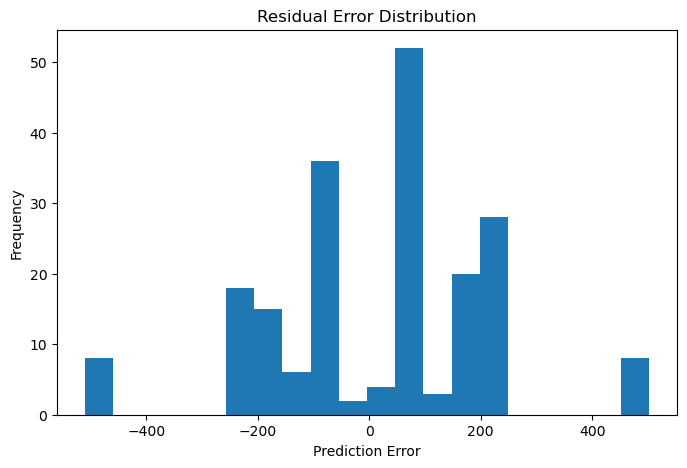

In [29]:
errors = y_test - predictions

plt.figure(figsize=(8,5))

plt.hist(errors, bins=20)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title("Residual Error Distribution")

plt.show()

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(importance)

                        Feature  Coefficient
3                          Year   242.489098
1                      Quantity   179.889064
6                   Gender_Male    20.609864
8  Product Category_Electronics    -4.320927
2                Price per Unit     2.493974
4                         Month     2.265272
7     Product Category_Clothing    -0.670436
0                           Age    -0.507410
5                           Day     0.470896


In [32]:
new_customer = pd.DataFrame({
    'Age': [35],
    'Quantity': [4],
    'Price per Unit': [500],
    'Year': [2026],
    'Month': [7],
    'Day': [1],
    'Gender_Male': [1],
    'Product Category_Clothing': [1],
    'Product Category_Electronics': [0]
})

prediction = model.predict(new_customer)

print("Predicted Total Amount =", prediction[0])

Predicted Total Amount = 2254.2036032741307
